In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import math 
import sklearn 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
#make a train-test split 

In [2]:
filename1 = 'Combined_Data.csv'
filename2 = 'Combined_Data_Two_weeks.csv'
new_data = pd.read_csv(filename1)
old_data = pd.read_csv(filename2) 
new_data['View Count'] = new_data['View Count'].str.replace(',', '').astype(int)
old_data['View Count'] = old_data['View Count'].str.replace(',', '').astype(int)
data = old_data
data['Post 2 Weeks View Count'] = new_data['View Count']
data['Video Posted'] = pd.to_datetime(data['Video Posted'])
data['Video Posted'] = data['Video Posted'].dt.tz_localize(None)
# 2. Define the reference date (February 11, 2025)
reference_date = pd.Timestamp('2025-02-11')
# 3. Calculate time difference in days, rounding to the nearest whole day
data['time_since_posting'] = (
    (reference_date - data['Video Posted']).dt.total_seconds() / 86400
).round().astype(int)
data

,Channel Name,Subscriber Count,Total Videos,Total Views,View Count,Like Count,Comment Count,Video Posted,Video Link,Post 2 Weeks View Count,time_since_posting
0,The Infographics Show,14800000,5354,6251451295,14149,936,225,2025-02-11 00:11:00,https://www.youtube.com/watch?v=w2SYMSemBI0&ab...,64213,0
1,The Infographics Show,14800000,5354,6251451295,267615,9021,1621,2025-02-09 15:11:00,https://www.youtube.com/watch?v=beWI6TOjXG4&ab...,562089,1
2,The Infographics Show,14800000,5354,6251451295,25730,338,26,2025-02-09 03:11:00,https://www.youtube.com/watch?v=XVS3vFs7sBU&ab...,43791,2
3,The Infographics Show,14800000,5354,6251451295,67402,1721,193,2025-02-08 15:11:00,https://www.youtube.com/watch?v=p8YmQPzknNg&ab...,82292,2
4,The Infographics Show,14800000,5354,6251451295,90882,3079,442,2025-02-08 00:37:00,https://www.youtube.com/watch?v=F9EWqjuWlwQ&ab...,185774,3
...,...,...,...,...,...,...,...,...,...,...,...
265,Physics Explained,238000,26,11500176,213650,8049,465,2025-01-20 21:00:06,https://www.youtube.com/watch?v=vjDvBP5IU-4,260821,21
266,Physics Explained,238000,26,11500176,87393,3349,259,2025-01-27 20:00:06,https://www.youtube.com/watch?v=zvyxArI67vw,97308,14
267,Physics Explained,238000,26,11500176,19475,1362,105,2025-01-12 17:59:29,https://www.youtube.com/watch?v=hMkUdTQ2amw,20035,29
268,Periodic Videos,1620000,729,290600849,46377,3688,262,2025-01-21 13:38:06,https://www.youtube.com/watch?v=xNbDe0K-p8w,47996,20


Slope: [1.21691673], Intercept: [3527.25876224]
R^2 (Train): 0.8288786415768372, R^2 (Test): 0.9888886100202928


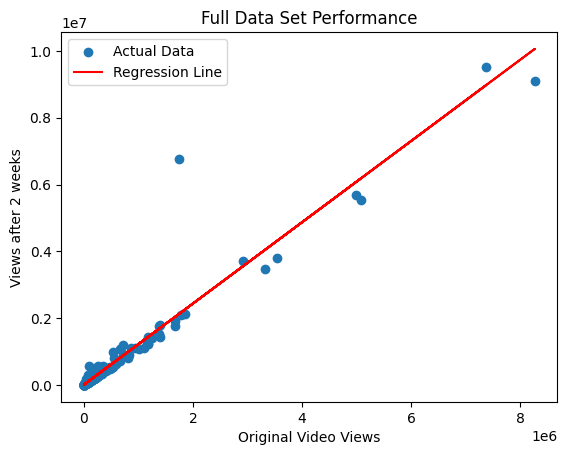

In [3]:
# Prepare data
a = np.array(data['View Count']).reshape(-1,1)
b = np.array(data['time_since_posting']).reshape(-1,1)
c = np.array(data['Post 2 Weeks View Count'])

x = data[['View Count']]
y = data[['Post 2 Weeks View Count']]

# Split data into 80% training and 20% testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(x_train, y_train)

# Model evaluation
slope = model.coef_[0]
intercept = model.intercept_
r_squared_train = model.score(x_train, y_train)
r_squared_test = model.score(x_test, y_test)
y_pred = model.predict(x_test)

print(f"Slope: {slope}, Intercept: {intercept}")
print(f"R^2 (Train): {r_squared_train}, R^2 (Test): {r_squared_test}")

# Plot results
plt.scatter(x,y, label="Actual Data")
plt.plot(x_test, y_pred, color='red', label="Regression Line")
plt.xlabel('Original Video Views')
plt.ylabel('Views after 2 weeks')
plt.title('Full Data Set Performance')
plt.legend()
plt.show()
